<a href="https://colab.research.google.com/github/carloseduardo2909/aulas_processamento_de_imagem/blob/main/RAP1_e_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Início da Prática
Arquivos gerados: cgpi1.svg, cgpi1.png, cgpi2_matricial.png, cgpi3_final.png
Início da Prática

--- Imagem do Passo 1 (Vetorial salva como PNG) ---


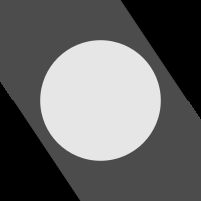


--- Imagem do Passo 2 (Círculo Matricial) ---


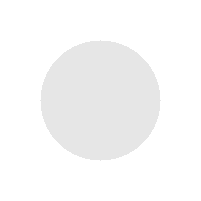


--- Imagem do Passo 3 (Conversão Vetorial para Matricial) ---


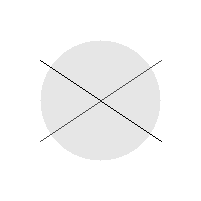


Arquivos gerados com sucesso!


In [ ]:
import cairo
import numpy as np
from PIL import Image
import math

# --- PASSO 1: IMAGEM VETORIAL ---
def criaImagemVetorial():
    # Inicializa superfície SVG (201x201 para manter proporção com a matricial)
    # Usaremos escala 1.0 para as coordenadas reais (0.0 a 1.0) conforme o roteiro
    surface = cairo.SVGSurface("cgpi1.svg", 201, 201)
    context = cairo.Context(surface)
    context.scale(201, 201) # Escala para usar coordenadas de 0 a 1

    # Reta 1: Preta de (0.2, 0.3) a (0.8, 0.7)
    context.set_source_rgb(0, 0, 0)
    context.set_line_width(0.01)
    context.move_to(0.2, 0.3)
    context.line_to(0.8, 0.7)
    context.stroke()

    # Reta 2: Cinza escuro de (0.8, 0.3) a (0.2, 0.7)
    context.set_source_rgb(0.3, 0.3, 0.3)
    context.move_to(0.8, 0.3)
    context.line_to(0.2, 0.7)
    context.stroke()

    # Círculo: Cinza claro, centro (0.5, 0.5), raio 0.3
    context.set_source_rgb(0.9, 0.9, 0.9) # Nível próximo a 230/255
    context.arc(0.5, 0.5, 0.3, 0, 2 * math.pi)
    context.fill() # Preenchido para seguir a lógica de sobreposição

    surface.finish()
    return surface

def passo1():
    criaImagemVetorial()
    # Para salvar em PNG no Colab a partir do SVG (usando Cairo)
    surface = cairo.ImageSurface(cairo.FORMAT_ARGB32, 201, 201)
    ctx = cairo.Context(surface)
    ctx.scale(201, 201)
    # Repete os desenhos para o PNG (simplificado)
    ctx.set_source_rgb(0, 0, 0)
    ctx.move_to(0.2, 0.3); ctx.line_to(0.8, 0.7); ctx.stroke()
    ctx.set_source_rgb(0.3, 0.3, 0.3)
    ctx.move_to(0.8, 0.3); ctx.line_to(0.2, 0.7); ctx.stroke()
    ctx.set_source_rgb(0.9, 0.9, 0.9)
    ctx.arc(0.5, 0.5, 0.3, 0, 2 * math.pi); ctx.fill()
    surface.write_to_png("cgpi1.png")

# --- PASSO 2: CÍRCULO MATRICIAL ---
def desenhaCirculo(f, c, r, g):
    xc, yc = c
    for x in range(f.shape[0]):
        for y in range(f.shape[1]):
            # Equação da circunferência: (x-xc)^2 + (y-yc)^2 <= r^2
            # Ajuste para garantir que r é um int para a comparação
            if (x - xc)**2 + (y - yc)**2 <= r**2:
                f[y, x] = g

def passo2():
    f = np.full((201, 201), 255, dtype=np.uint8)
    desenhaCirculo(f, (100, 100), 60, 230)
    Image.fromarray(f).save("cgpi2_matricial.png")

# --- PASSO 3: RETA E CONVERSÃO ---
def desenhaReta(f, p, q, g):
    x0, y0 = p
    x1, y1 = q
    # Implementação simples de reta (Bresenham ou DDA)
    num_pontos = max(abs(x1 - x0), abs(y1 - y0)) + 1
    for i in range(num_pontos):
        t = i / (num_pontos - 1) if num_pontos > 1 else 0
        x = int(round(x0 + t * (x1 - x0)))
        y = int(round(y0 + t * (y1 - y0)))
        if 0 <= x < f.shape[1] and 0 <= y < f.shape[0]:
            f[y, x] = g

def passo3():
    f = np.full((201, 201), 255, dtype=np.uint8)

    # Conversão de coordenadas: valor_real * 201
    # Desenhar o círculo primeiro para que as retas fiquem visíveis por cima
    desenhaCirculo(f, (round(0.5*201), round(0.5*201)), round(0.3*201), 230)

    # Reta 1
    desenhaReta(f, (round(0.2*201), round(0.3*201)), (round(0.8*201), round(0.7*201)), 0)
    # Reta 2
    desenhaReta(f, (round(0.8*201), round(0.3*201)), (round(0.2*201), round(0.7*201)), 77)

    Image.fromarray(f).save("cgpi3_final.png")

# Execução
print("Início da Prática")
passo1()
passo2()
passo3()
print("Arquivos gerados: cgpi1.svg, cgpi1.png, cgpi2_matricial.png, cgpi3_final.png")



import cv2
from google.colab.patches import cv2_imshow

# Execução dos passos definidos anteriormente
print("Início da Prática")
passo1()
passo2()
passo3()

# Exibição das imagens geradas
print("\n--- Imagem do Passo 1 (Vetorial salva como PNG) ---")
cv2_imshow(cv2.imread("cgpi1.png"))

print("\n--- Imagem do Passo 2 (Círculo Matricial) ---")
cv2_imshow(cv2.imread("cgpi2_matricial.png"))

print("\n--- Imagem do Passo 3 (Conversão Vetorial para Matricial) ---")
cv2_imshow(cv2.imread("cgpi3_final.png"))

print("\nArquivos gerados com sucesso!")


Pontos 3D normalizados (x, y, z):
[np.float64(-7.643694886615098), np.float64(2.7512101257842247), np.float64(-1.0)]
[np.float64(-4.442318339916282), np.float64(2.324359919557715), np.float64(-1.0)]
[np.float64(-3.5187892927590028), np.float64(1.190698608682877), np.float64(-1.0)]
[np.float64(-2.544695575846551), np.float64(1.3405591805155617), np.float64(-1.0)]
[np.float64(-4.601493690531005), np.float64(1.1906986086828775), np.float64(-1.0)]
[np.float64(-3.3276788299531828), np.float64(1.340559180515562), np.float64(-1.0)]
[np.float64(-2.7642109607144905), np.float64(0.6263664232830815), np.float64(-1.0)]
[np.float64(-2.1927526343546253), np.float64(0.8549497538270271), np.float64(-1.0)]


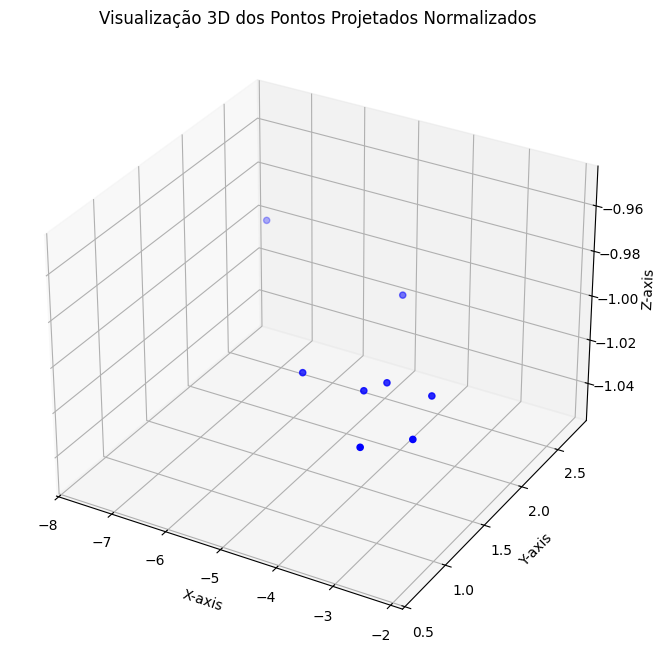

In [16]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def normalizar_coordenadas_homogeneas(pontos_homogeneos):
    pontos_normalizados = []
    for p in pontos_homogeneos:
        if p[3] != 0:  # Evitar divisão por zero
            pontos_normalizados.append([p[0]/p[3], p[1]/p[3], p[2]/p[3]])
        else:
            # Lidar com o caso de w = 0 (pontos no infinito, projeção paralela etc.)
            # Neste caso, vamos retornar None ou alguma indicação de ponto inválido para plotagem
            pontos_normalizados.append(None)
    # Remover pontos None, se houver
    return [p for p in pontos_normalizados if p is not None]

# Normalizar os pontos projetados
pontos_3d_normalizados = normalizar_coordenadas_homogeneas(pontos_projetados)

print("\nPontos 3D normalizados (x, y, z):")
for p in pontos_3d_normalizados:
    print(p)

# Extrair coordenadas para plotagem
x = [p[0] for p in pontos_3d_normalizados]
y = [p[1] for p in pontos_3d_normalizados]
z = [p[2] for p in pontos_3d_normalizados]

# Criar a figura e o eixo 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plotar os pontos
ax.scatter(x, y, z, c='b', marker='o')

# Adicionar rótulos
ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')
ax.set_zlabel('Z-axis')
ax.set_title('Visualização 3D dos Pontos Projetados Normalizados')

# Mostrar o gráfico
plt.show()